# 03 · Drift, adaptación por olvido y decisión

Qué se responde aquí:

1. ¿Compensa olvidar? ¿Qué tamaño de ventana?
2. ¿Los detectores encuentran el cambio, y con cuánto retraso?
3. ¿Qué **no** consigue el sistema?

Este es el experimento central: cinco estrategias sobre **los mismos eventos**, la
misma semilla, la misma política y la misma familia.

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent          # el notebook puede abrirse desde notebooks/
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fraud_adaptive.pipeline import load_configs
from fraud_adaptive.tracking import read_json

CONFIGS = load_configs(ROOT / "configs")
RUN_DIR = ROOT / CONFIGS["base"]["paths"]["runs"] / "principal"
REPORTS = ROOT / CONFIGS["base"]["paths"]["reports"]

MANIFEST = read_json(ROOT / CONFIGS["base"]["paths"]["manifests"] / "sources.json")
DATA_SOURCE = MANIFEST.get("data_source", "desconocido")

if DATA_SOURCE == "sintetico_sustituto":
    print("AVISO: los datos son un SUSTITUTO SINTETICO. Ninguna cifra describe IEEE-CIS.")
else:
    print("Datos: IEEE-CIS Fraud Detection (particion train).")
print("Run:", RUN_DIR)

Datos: IEEE-CIS Fraud Detection (particion train).
Run: C:\Users\25por\OneDrive\Desktop\utec\planifica\PLANIFICA_PROYECTO01\runs\principal


## 1. El protocolo temporal

Las tres reservas de 7 días son idénticas para todas las estrategias. Eso es lo que hace que una diferencia de costo sea atribuible al **tamaño de ventana** y no a otra cosa.

In [2]:
splits = read_json(ROOT / CONFIGS["base"]["paths"]["manifests"] / "splits.json")

print(f"L = {splits['label_delay_days']} días   cadencia = {splits['cadence_days']} días")
print(f"Regla de elegibilidad: {splits['eligibility_rule']}\n")

filas = []
for estrategia, versiones in splits["versions"].items():
    for v in versiones:
        filas.append({
            "version": v["version_id"], "T": v["update_time"], "c": v["cutoff"],
            "predictor": f"[{v['predictor'][0]},{v['predictor'][1]})",
            "dias_fit": v["predictor_days"],
            "calibracion": f"[{v['calibration'][0]},{v['calibration'][1]})",
            "H": f"[{v['promotion_validation'][0]},{v['promotion_validation'][1]})",
        })
pd.DataFrame(filas)

L = 30 días   cadencia = 15 días
Regla de elegibilidad: available_at < cutoff (estricto)



,version,T,c,predictor,dias_fit,calibracion,H
0,S0_T120,120,90,"[0,69)",69,"[69,76)","[83,90)"
1,E15_T120,120,90,"[0,69)",69,"[69,76)","[83,90)"
2,E15_T135,135,105,"[0,84)",84,"[84,91)","[98,105)"
3,E15_T150,150,120,"[0,99)",99,"[99,106)","[113,120)"
4,E15_T165,165,135,"[0,114)",114,"[114,121)","[128,135)"
5,W30_T120,120,90,"[60,69)",9,"[69,76)","[83,90)"
6,W30_T135,135,105,"[75,84)",9,"[84,91)","[98,105)"
7,W30_T150,150,120,"[90,99)",9,"[99,106)","[113,120)"
8,W30_T165,165,135,"[105,114)",9,"[114,121)","[128,135)"
9,W60_T120,120,90,"[30,69)",39,"[69,76)","[83,90)"


## 2. Resultado central

Una fila por estrategia, con las tres familias de métricas. `S0` y `E15` son **referencias no desplegables**.

In [3]:
adaptacion = pd.read_csv(REPORTS / "tables" / "adaptacion.csv")
adaptacion[["estrategia", "ap", "skill", "brier", "f1", "costo_um_tx",
            "costo_ic_low", "costo_ic_high", "bloqueo_legitimas",
            "n_revisiones", "versiones_activadas"]].round(4)

,estrategia,ap,skill,brier,f1,costo_um_tx,costo_ic_low,costo_ic_high,bloqueo_legitimas,n_revisiones,versiones_activadas
0,S0,0.4799,0.4614,0.0239,0.3542,1.5282,1.4398,1.6221,0.1079,9300,1
1,E15,0.4870,0.4687,0.0238,0.3501,1.4961,1.4024,1.6041,0.1151,9300,3
2,W30,0.4267,0.4062,0.0252,0.2459,1.7924,1.6546,1.9247,0.1282,9300,2
3,W60,0.4636,0.4445,0.0245,0.3373,1.6262,1.4940,1.7816,0.1224,9300,3
4,W90,0.4775,0.4589,0.0241,0.3485,1.5230,1.4434,1.6228,0.1187,9300,3


### Degradación por bloque

Aquí se ve si el olvido sirve: una ventana corta debería sostener el AP mientras el estático cae.

In [4]:
adaptacion[["estrategia", "ap_B1", "ap_B2", "ap_B3", "ap_B4"]].round(4)

,estrategia,ap_B1,ap_B2,ap_B3,ap_B4
0,S0,0.5255,0.3882,0.4727,0.5092
1,E15,0.5255,0.3882,0.4941,0.5366
2,W30,0.4771,0.3238,0.4270,0.4720
3,W60,0.5102,0.3531,0.4811,0.5173
4,W90,0.5255,0.3882,0.4787,0.5224


### Diferencia pareada frente a las referencias

Remuestreo de bloques contiguos de 7 días sobre los **mismos eventos**. Un intervalo que no cruza el cero indica una diferencia consistente.

In [5]:
cols = [c for c in adaptacion.columns if c.startswith("delta_costo_vs_")]
adaptacion[["estrategia"] + cols].round(4)

,estrategia,delta_costo_vs_S0,delta_costo_vs_S0_ic_low,delta_costo_vs_S0_ic_high,delta_costo_vs_E15,delta_costo_vs_E15_ic_low,delta_costo_vs_E15_ic_high
0,S0,0.0000,0.0000,0.0000,0.0322,0.0086,0.0575
1,E15,-0.0322,-0.0575,-0.0086,0.0000,0.0000,0.0000
2,W30,0.2642,0.1743,0.3670,0.2964,0.2118,0.4006
3,W60,0.0980,0.0087,0.1962,0.1301,0.0538,0.2187
4,W90,-0.0052,-0.0350,0.0260,0.0269,-0.0012,0.0627


## 3. ¿Se cumplen los objetivos declarados?

Un objetivo **puede incumplirse**. Se reporta el nivel realmente obtenido, no el objetivo.

In [6]:
objetivos = CONFIGS["decision"]["diagnostic_targets"]
tabla = adaptacion[["estrategia", "recall_at_fpr1", "fpr_obtenido",
                    "recall_at_precision80", "precision_obtenida"]].round(4)
print(f"Objetivos: FPR <= {objetivos['fpr_target']}, precisión >= {objetivos['precision_target']}\n")
display(tabla)

print("\nFPR objetivo alcanzado en test:",
      bool((tabla['fpr_obtenido'] <= objetivos['fpr_target']).any()))
print("Precisión objetivo alcanzada en test:",
      bool((tabla['precision_obtenida'] >= objetivos['precision_target']).any()))
print("\nLos umbrales se eligieron en validación y se aplicaron CONGELADOS.")
print("Que no se sostengan en test es un resultado, no un error a corregir moviendo el umbral.")

Objetivos: FPR <= 0.01, precisión >= 0.8



,estrategia,recall_at_fpr1,fpr_obtenido,recall_at_precision80,precision_obtenida
0,S0,0.4216,0.0134,0.3483,0.7265
1,E15,0.4367,0.0139,0.3497,0.7248
2,W30,0.3835,0.0139,0.2911,0.7315
3,W60,0.4278,0.0142,0.3337,0.7034
4,W90,0.4306,0.0145,0.3465,0.7154



FPR objetivo alcanzado en test: False
Precisión objetivo alcanzada en test: False

Los umbrales se eligieron en validación y se aplicaron CONGELADOS.
Que no se sostengan en test es un resultado, no un error a corregir moviendo el umbral.


## 4. Señales de drift y sus dos relojes

KS/PSI y S1 están disponibles el mismo día. ADWIN observa el **error real** y por eso llega L=30 días después.

In [7]:
drift_path = RUN_DIR / "drift_log.csv"
if drift_path.exists():
    drift = pd.read_csv(drift_path)
    alertas = drift[drift["alerta"].fillna(False).astype(bool)] if "alerta" in drift else pd.DataFrame()
    print(f"Registros de señal: {len(drift)}   alertas: {len(alertas)}")
    if not alertas.empty:
        display(alertas.groupby("senal").agg(
            n_alertas=("senal", "size"),
            primer_dia=("dia_evento", "min"),
            retraso_medio=("retraso_dias", "mean"),
        ).round(2))
else:
    print("Sin bitácora de drift en este run.")

Registros de señal: 373   alertas: 30


,n_alertas,primer_dia,retraso_medio
senal,,,
S1,1,120,0.0
S_KS_PSI,29,153,0.0


In [8]:
adwin_path = RUN_DIR / "adwin_detections.csv"
if adwin_path.exists():
    adwin = pd.read_csv(adwin_path)
    print(f"Detecciones de ADWIN: {len(adwin)}")
    display(adwin[["estrategia", "version_id", "dia_evento", "dia_disponibilidad",
                   "retraso_dias", "n_updates"]])
else:
    print("ADWIN no detectó cambios en ninguna versión.")

Detecciones de ADWIN: 2


,estrategia,version_id,dia_evento,dia_disponibilidad,retraso_dias,n_updates
0,S0,S0_T120,144,174,30,80672
1,S0,S0_T120,170,200,30,162752


### El detector, probado contra verdad conocida

Validación del **instrumento**: no son resultados sobre fraude.

In [9]:
pd.read_csv(REPORTS / "tables" / "adwin_selftest.csv")

,stream,n_obs,cambio_real,n_detecciones,primera_deteccion,retardo_obs,falsas_alarmas,delta,clock
0,stationary,2000,no,0,NaN,NaN,0,0.002,32
1,jump,2000,si (obs 1000),1,1055.0,55.0,0,0.002,32


## 5. Sensibilidad económica

Rescoring de predicciones guardadas con la política **congelada**. Responde *cuánto cambiaría la conclusión*, no *qué política sería óptima*.

In [10]:
sens_path = REPORTS / "tables" / "sensibilidad_economica.csv"
if sens_path.exists():
    display(pd.read_csv(sens_path).round(4))
else:
    print("Sensibilidad no disponible en este run.")

,escenario,c_fp,c_review,r_h,f_h,costo_por_tx,n_revisiones,n_bloqueadas,monto_fraude_evitado,estrategia,nota
0,bajo,1.0,0.5,0.9,0.02,0.9621,9300,64368,845127.935,W30,Politica congelada; sin nuevos fits ni reoptim...
1,base,5.0,1.0,0.9,0.02,1.7924,9300,25232,752734.235,W30,Politica congelada; sin nuevos fits ni reoptim...
2,alto,10.0,2.0,0.9,0.02,2.3523,9300,15881,684021.698,W30,Politica congelada; sin nuevos fits ni reoptim...
3,estres_analista,5.0,1.0,0.8,0.05,1.8391,9300,25232,745793.429,W30,Politica congelada; sin nuevos fits ni reoptim...


## 6. Equidad operativa

Segmentos de **negocio**. IEEE-CIS no tiene atributos protegidos verificables: esto no es una auditoría demográfica.

In [11]:
seg_path = REPORTS / "tables" / "segmentos.csv"
if seg_path.exists():
    seg = pd.read_csv(seg_path)
    display(seg[seg["soporte_suficiente"]][
        ["variable", "grupo", "n_legitimas", "tasa_bloqueo", "brecha_pp", "alerta_brecha"]
    ].round(4))
    print(f"\nGrupos con evidencia insuficiente: {int(seg['evidencia_insuficiente'].sum())}")
    print("Se conservan en la tabla: ocultarlos daría una falsa impresión de cobertura.")

,variable,grupo,n_legitimas,tasa_bloqueo,brecha_pp,alerta_brecha
0,P_emaildomain,gmail.com,65729,0.1475,1.9390,False
1,P_emaildomain,yahoo.com,29671,0.1186,-0.9554,False
2,P_emaildomain,desconocido,29134,0.1157,-1.2414,False
3,P_emaildomain,hotmail.com,11725,0.0887,-3.9456,True
4,P_emaildomain,anonymous.com,9977,0.1293,0.1143,False
5,P_emaildomain,aol.com,8250,0.1183,-0.9852,False
6,P_emaildomain,comcast.net,2020,0.1312,0.3033,False
7,P_emaildomain,icloud.com,1875,0.0917,-3.6422,True
8,P_emaildomain,outlook.com,1372,0.1356,0.7414,False
9,P_emaildomain,att.net,1297,0.0455,-8.2665,True



Grupos con evidencia insuficiente: 49
Se conservan en la tabla: ocultarlos daría una falsa impresión de cobertura.


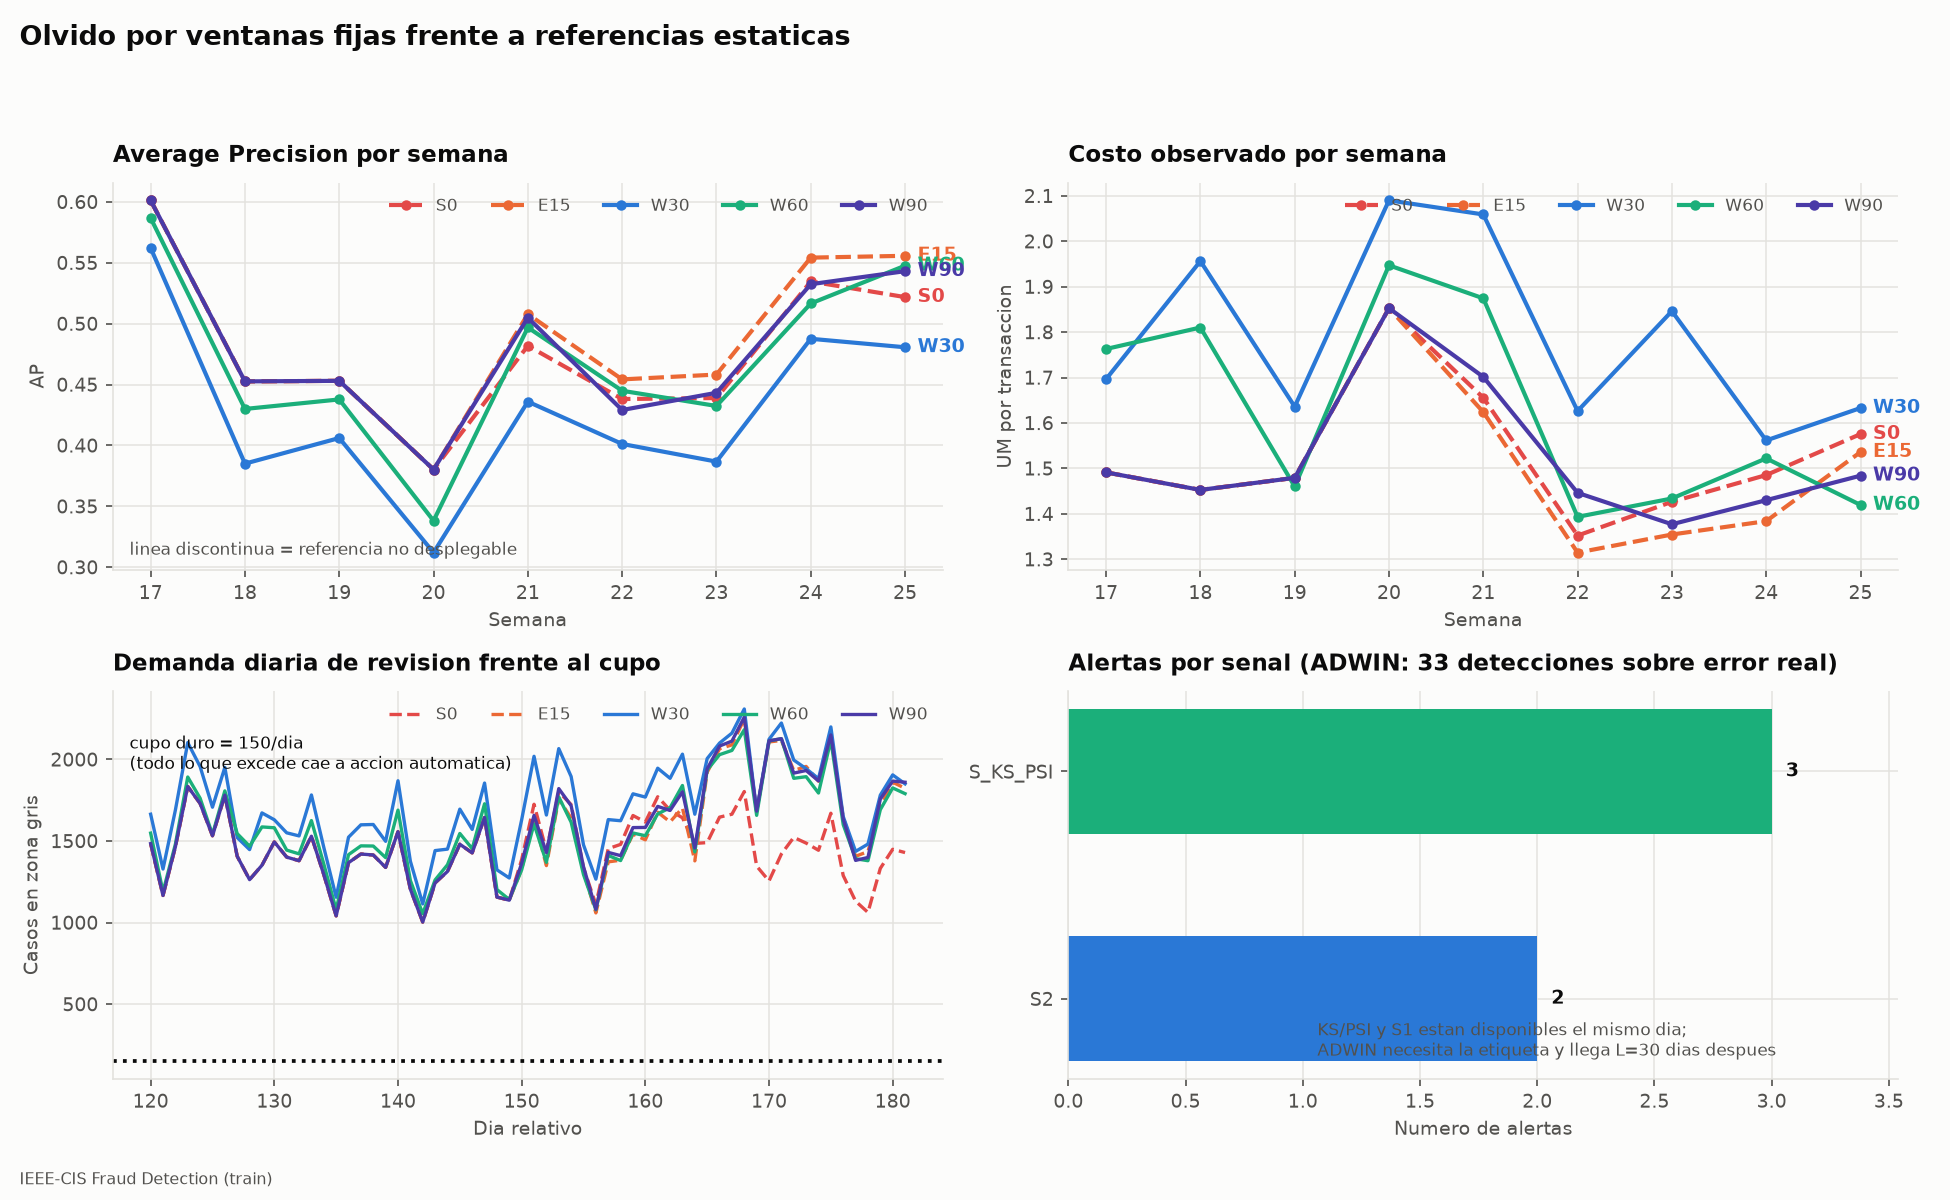

In [12]:
from IPython.display import Image, display
display(Image(filename=str(REPORTS / "figures" / "drift_adaptacion.png")))

## 7. Costo de cómputo

In [13]:
display(pd.read_csv(REPORTS / "tables" / "costos_computo.csv").round(2))

presupuesto = read_json(RUN_DIR / "budget.json")
print(f"\nConsumido: {presupuesto['consumed_minutes']:.1f} min de "
      f"{presupuesto['total_minutes']:.0f}  ({presupuesto['remaining_minutes']:.1f} restantes)")

,kind,n_tareas,segundos,minutos,porcentaje_presupuesto
0,fit_tuning,18,1101.54,18.36,3.82
1,fit_final,6,590.60,9.84,2.05
2,backtest,1,192.75,3.21,0.67
3,fit_seleccion_W,3,21.79,0.36,0.08
4,datos,5,16.80,0.28,0.06
5,fit_adaptivo,2,15.48,0.26,0.05



Consumido: 21.9 min de 480  (458.1 restantes)


## 8. Qué no demuestra este experimento

- No es una validación prospectiva: es un backtest retrospectivo, y la selección
  previa del dataset ya examinó periodos tardíos.
- Los costos son simulados bajo supuestos declarados; no hay ahorro causal medido.
- Una sola semilla no permite afirmar variabilidad entre semillas.
- La ventana recomendada es la elegida **en desarrollo**. Si otra resulta mejor en
  el test final, eso es un diagnóstico retrospectivo, no un permiso para retunear.